# FMD + PRRSV Accuracy Summary

Notebook này tạo bảng accuracy ngắn gọn cho cả FMD và PRRSV.

Quy tắc chính: với từng gene, chỉ evaluate trên những query records thật sự có same-gene truth. Ví dụ `ORF7` chỉ tính trên 94 records có ORF7 trong truth, không tính các records thiếu annotation ORF7.

Metric chính:

- `total`: số record có truth gene đó.
- `exact`: pred name + start + end khớp hoàn toàn.
- `coord_only`: tọa độ đúng theo IoU threshold nhưng không exact.
- `failed`: không exact và cũng không coordinate-correct.
- `accuracy_pct`: `(exact + coord_only) / total * 100`.

In [1]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import app.validation._shared.validation_utils as validation_utils
importlib.reload(validation_utils)
from app.validation._shared.validation_utils import *

TIER = 'strict_clean'
BASE_DIR = ROOT / 'app' / 'validation' / '04_tblastn_truth_breakdown_100seq' / 'tiers' / TIER
INPUT_DIR = BASE_DIR / 'inputs'
OUTPUT_DIR = BASE_DIR / 'summary_outputs'
DATA_DIR = ROOT / 'app' / 'data'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 160)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})

BASE_DIR, OUTPUT_DIR

(PosixPath('/Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/04_tblastn_truth_breakdown_100seq/tiers/strict_clean'),
 PosixPath('/Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/04_tblastn_truth_breakdown_100seq/tiers/strict_clean/summary_outputs'))

## Config

Default là dùng output mới nhất đã chạy:

- FMD: terminal extrapolation output.
- PRRSV: start-rescue experimental output.

Nếu muốn rerun tblastn từ đầu, đổi `RUN_TBLASTN = True`.

In [2]:
RUN_TBLASTN = False

VIRUS_CONFIGS = {
    'FMD': {
        'virus_label': 'FMD',
        'ref_path': DATA_DIR / 'FMD_ref_test.gb',
        'query_path': INPUT_DIR / 'FMD_records.gb',
        'cached_prediction_path': BASE_DIR / 'terminal_extrapolation_outputs' / 'fmd_tblastn_vs_truth.tsv',
        'rerun_output_dir': OUTPUT_DIR / 'fmd_rerun',
    },
    'PRRSV': {
        'virus_label': 'PRRS',
        'ref_path': DATA_DIR / 'PRRS_ref_test.gb',
        'query_path': INPUT_DIR / 'PRRS_records.gb',
        'cached_prediction_path': BASE_DIR / 'prrsv_start_rescue_full_outputs' / 'prrsv_tblastn_vs_truth_experimental.tsv',
        'rerun_output_dir': OUTPUT_DIR / 'prrsv_rerun',
    },
}

for virus, cfg in VIRUS_CONFIGS.items():
    print(virus, cfg['cached_prediction_path'], cfg['cached_prediction_path'].exists())

FMD /Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/04_tblastn_truth_breakdown_100seq/tiers/strict_clean/terminal_extrapolation_outputs/fmd_tblastn_vs_truth.tsv True
PRRSV /Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/04_tblastn_truth_breakdown_100seq/tiers/strict_clean/prrsv_start_rescue_full_outputs/prrsv_tblastn_vs_truth_experimental.tsv True


## Helpers

In [3]:
def load_or_run_predictions(config):
    if RUN_TBLASTN:
        df, summary = run_tblastn_against_truth(
            virus_label=config['virus_label'],
            ref_path=config['ref_path'],
            query_path=config['query_path'],
            output_dir=config['rerun_output_dir'],
            progress=True,
        )
        return df
    path = config['cached_prediction_path']
    if not path.exists():
        raise FileNotFoundError(
            f'Missing cached prediction file: {path}. Set RUN_TBLASTN=True to regenerate.'
        )
    return pd.read_csv(path, sep='	')


def build_truth_presence(config):
    bundle = load_reference_bundle(config['ref_path'])
    ref_features = bundle['features']
    ref_model = pd.DataFrame(ref_features).copy()
    ref_model['ref_len'] = ref_model['end'] - ref_model['start'] + 1
    ref_model = (
        ref_model.rename(columns={'name': 'ref_name', 'start': 'ref_start', 'end': 'ref_end'})
        [['ref_name', 'ref_start', 'ref_end', 'ref_len', 'strand']]
        .sort_values(['ref_start', 'ref_end'])
        .reset_index(drop=True)
    )
    ref_gene_names = ref_model['ref_name'].dropna().astype(str).tolist()
    records = load_genbank_records(config['query_path'])
    presence_rows = []
    for record in records:
        truth_features, _ = parse_validation_truth_features(
            record,
            bundle['alias_lookup'],
            bundle['feature_type'],
            ref_features,
            config['virus_label'],
        )
        truth_names = {feature['name'] for feature in truth_features}
        for gene in ref_gene_names:
            presence_rows.append({
                'record_id': record.id,
                'gene': gene,
                'has_truth_gene': gene in truth_names,
            })
    return ref_model, pd.DataFrame(presence_rows)


def summarize_per_gene(pred_df, truth_presence, ref_model, virus_name):
    rows = []
    for gene in ref_model['ref_name'].tolist():
        truth_records = set(
            truth_presence[truth_presence['gene'].eq(gene) & truth_presence['has_truth_gene'].eq(True)]['record_id']
        )
        gene_rows = pred_df[pred_df['ref_name'].eq(gene) & pred_df['record_id'].isin(truth_records)].copy()
        total = len(gene_rows)
        exact = int(gene_rows['exact_match'].fillna(False).sum()) if total else 0
        coord_correct = int(gene_rows['coord_correct'].fillna(False).sum()) if total else 0
        coord_only = coord_correct - exact
        failed = total - coord_correct
        no_hit = int(gene_rows['status'].fillna('').eq('no_hit').sum()) if total and 'status' in gene_rows else 0
        rows.append({
            'virus': virus_name,
            'gene': gene,
            'total': total,
            'exact': exact,
            'coord_only': coord_only,
            'coord_correct': coord_correct,
            'failed': failed,
            'no_hit': no_hit,
            'exact_pct': round(exact / total * 100, 2) if total else None,
            'coord_only_pct': round(coord_only / total * 100, 2) if total else None,
            'failed_pct': round(failed / total * 100, 2) if total else None,
            'accuracy_pct': round((exact + coord_only) / total * 100, 2) if total else None,
        })
    return pd.DataFrame(rows)


def summarize_overall(per_gene_df):
    rows = []
    for virus, df in per_gene_df.groupby('virus', sort=False):
        total = int(df['total'].sum())
        exact = int(df['exact'].sum())
        coord_only = int(df['coord_only'].sum())
        coord_correct = int(df['coord_correct'].sum())
        failed = int(df['failed'].sum())
        rows.append({
            'virus': virus,
            'total': total,
            'exact': exact,
            'coord_only': coord_only,
            'coord_correct': coord_correct,
            'failed': failed,
            'exact_pct': round(exact / total * 100, 2) if total else None,
            'coord_only_pct': round(coord_only / total * 100, 2) if total else None,
            'failed_pct': round(failed / total * 100, 2) if total else None,
            'accuracy_pct': round((exact + coord_only) / total * 100, 2) if total else None,
        })
    total = int(per_gene_df['total'].sum())
    exact = int(per_gene_df['exact'].sum())
    coord_only = int(per_gene_df['coord_only'].sum())
    coord_correct = int(per_gene_df['coord_correct'].sum())
    failed = int(per_gene_df['failed'].sum())
    rows.append({
        'virus': 'ALL',
        'total': total,
        'exact': exact,
        'coord_only': coord_only,
        'coord_correct': coord_correct,
        'failed': failed,
        'exact_pct': round(exact / total * 100, 2) if total else None,
        'coord_only_pct': round(coord_only / total * 100, 2) if total else None,
        'failed_pct': round(failed / total * 100, 2) if total else None,
        'accuracy_pct': round((exact + coord_only) / total * 100, 2) if total else None,
    })
    return pd.DataFrame(rows)

## Load Predictions And Build Summary

In [4]:
all_per_gene = []
all_prediction_dfs = {}
all_ref_models = {}
all_truth_presence = {}

for virus_name, config in VIRUS_CONFIGS.items():
    print(f'Processing {virus_name}...')
    pred_df = load_or_run_predictions(config)
    ref_model, truth_presence = build_truth_presence(config)
    per_gene = summarize_per_gene(pred_df, truth_presence, ref_model, virus_name)
    all_prediction_dfs[virus_name] = pred_df
    all_ref_models[virus_name] = ref_model
    all_truth_presence[virus_name] = truth_presence
    all_per_gene.append(per_gene)

per_gene_summary = pd.concat(all_per_gene, ignore_index=True)
per_gene_summary.to_csv(OUTPUT_DIR / 'fmd_prrsv_per_gene_accuracy.tsv', sep='	', index=False)
per_gene_summary

Processing FMD...
Processing PRRSV...


,virus,gene,total,exact,coord_only,coord_correct,failed,no_hit,exact_pct,coord_only_pct,failed_pct,accuracy_pct
0,FMD,Lpro,96,96,0,96,0,0,100.00,0.00,0.00,100.00
1,FMD,VP4,95,95,0,95,0,0,100.00,0.00,0.00,100.00
2,FMD,VP2,96,95,0,95,1,0,98.96,0.00,1.04,98.96
3,FMD,VP3,95,95,0,95,0,0,100.00,0.00,0.00,100.00
4,FMD,VP1,95,79,16,95,0,0,83.16,16.84,0.00,100.00
5,FMD,2A,96,79,0,79,17,1,82.29,0.00,17.71,82.29
6,FMD,2B,96,96,0,96,0,0,100.00,0.00,0.00,100.00
7,FMD,2C,96,96,0,96,0,0,100.00,0.00,0.00,100.00
8,FMD,3A,96,95,0,95,1,0,98.96,0.00,1.04,98.96
9,FMD,3B,96,96,0,96,0,0,100.00,0.00,0.00,100.00


## Per-Gene Accuracy Table

In [5]:
display_cols = [
    'virus', 'gene', 'total', 'exact', 'coord_only', 'failed',
    'exact_pct', 'coord_only_pct', 'failed_pct', 'accuracy_pct'
]
per_gene_table = per_gene_summary[display_cols].copy()
per_gene_table

,virus,gene,total,exact,coord_only,failed,exact_pct,coord_only_pct,failed_pct,accuracy_pct
0,FMD,Lpro,96,96,0,0,100.00,0.00,0.00,100.00
1,FMD,VP4,95,95,0,0,100.00,0.00,0.00,100.00
2,FMD,VP2,96,95,0,1,98.96,0.00,1.04,98.96
3,FMD,VP3,95,95,0,0,100.00,0.00,0.00,100.00
4,FMD,VP1,95,79,16,0,83.16,16.84,0.00,100.00
5,FMD,2A,96,79,0,17,82.29,0.00,17.71,82.29
6,FMD,2B,96,96,0,0,100.00,0.00,0.00,100.00
7,FMD,2C,96,96,0,0,100.00,0.00,0.00,100.00
8,FMD,3A,96,95,0,1,98.96,0.00,1.04,98.96
9,FMD,3B,96,96,0,0,100.00,0.00,0.00,100.00


## Overall Accuracy

Overall = cộng tất cả gene-level denominators lại. `accuracy_pct = (exact + coord_only) / total`.

In [6]:
overall_summary = summarize_overall(per_gene_summary)
overall_summary.to_csv(OUTPUT_DIR / 'fmd_prrsv_overall_accuracy.tsv', sep='	', index=False)
overall_summary

,virus,total,exact,coord_only,coord_correct,failed,exact_pct,coord_only_pct,failed_pct,accuracy_pct
0,FMD,1149,1114,16,1130,19,96.95,1.39,1.65,98.35
1,PRRSV,761,674,84,758,3,88.57,11.04,0.39,99.61
2,ALL,1910,1788,100,1888,22,93.61,5.24,1.15,98.85


## Visual Summary

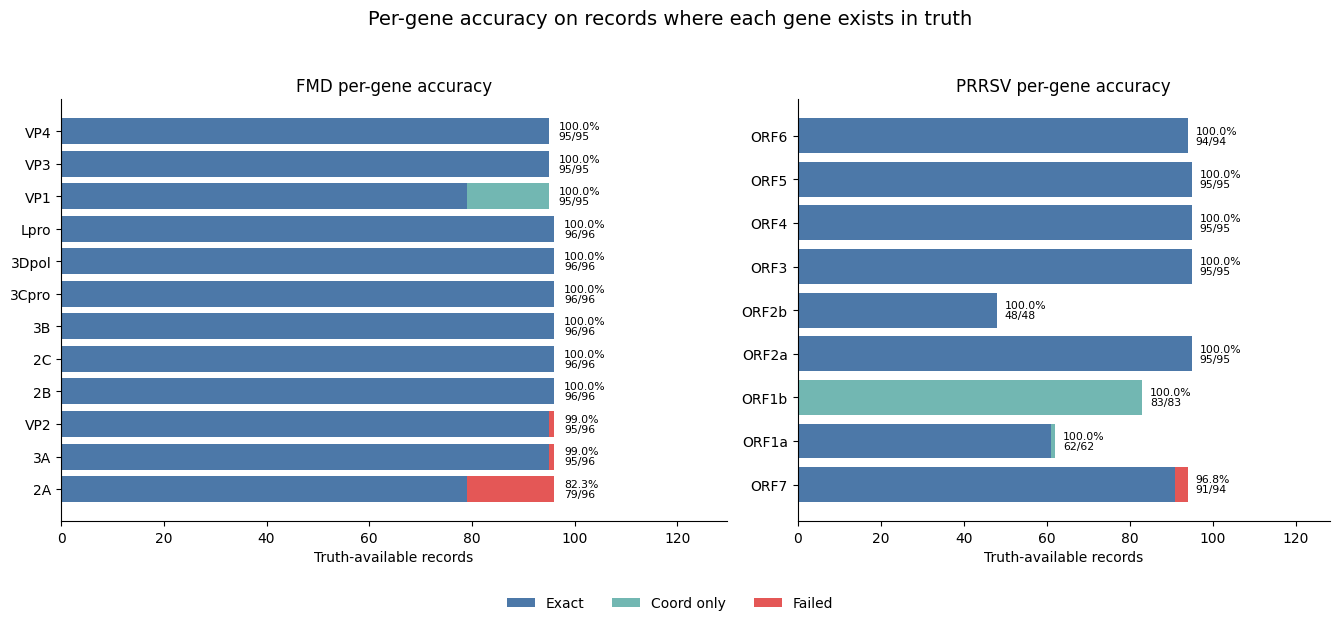

In [7]:
plot_df = per_gene_summary.copy()
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.2), gridspec_kw={'width_ratios': [1.25, 1]})

for ax, virus in zip(axes, ['FMD', 'PRRSV']):
    df = plot_df[plot_df['virus'].eq(virus)].copy()
    df = df.sort_values(['accuracy_pct', 'gene'], ascending=[True, True])
    y = range(len(df))
    ax.barh(y, df['exact'], label='Exact', color='#4C78A8')
    ax.barh(y, df['coord_only'], left=df['exact'], label='Coord only', color='#72B7B2')
    ax.barh(y, df['failed'], left=df['exact'] + df['coord_only'], label='Failed', color='#E45756')
    ax.set_yticks(list(y), df['gene'])
    ax.set_xlabel('Truth-available records')
    ax.set_title(f'{virus} per-gene accuracy')
    max_total = max(df['total'].max(), 1)
    ax.set_xlim(0, max_total * 1.35)
    for yi, row in zip(y, df.to_dict('records')):
        ax.text(row['total'] + max_total * 0.02, yi, f"{row['accuracy_pct']:.1f}%\n{int(row['coord_correct'])}/{int(row['total'])}", va='center', ha='left', fontsize=7.8, linespacing=1.0)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Per-gene accuracy on records where each gene exists in truth', y=0.98, fontsize=14)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig(OUTPUT_DIR / 'fmd_prrsv_per_gene_accuracy.png', bbox_inches='tight')
plt.show()

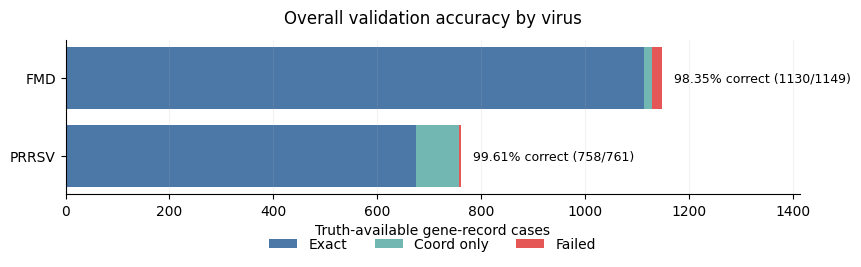

In [8]:
overall_plot = overall_summary[overall_summary['virus'].ne('ALL')].copy().sort_values('virus', ascending=False)
fig, ax = plt.subplots(figsize=(8.8, 3.4))
y = range(len(overall_plot))

ax.barh(y, overall_plot['exact'], label='Exact', color='#4C78A8')
ax.barh(y, overall_plot['coord_only'], left=overall_plot['exact'], label='Coord only', color='#72B7B2')
ax.barh(y, overall_plot['failed'], left=overall_plot['exact'] + overall_plot['coord_only'], label='Failed', color='#E45756')
ax.set_yticks(list(y), overall_plot['virus'])
ax.set_xlabel('Truth-available gene-record cases')
ax.set_title('Overall validation accuracy by virus', pad=12)
max_total = overall_plot['total'].max()
ax.set_xlim(0, max_total * 1.23)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.16)

for yi, row in zip(y, overall_plot.to_dict('records')):
    label = f"{row['accuracy_pct']:.2f}% correct ({int(row['coord_correct'])}/{int(row['total'])})"
    ax.text(row['total'] + max_total * 0.02, yi, label, va='center', ha='left', fontsize=9)

ax.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.20))
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig(OUTPUT_DIR / 'fmd_prrsv_overall_accuracy.png', bbox_inches='tight', dpi=160)
plt.show()

## Failed Cases For Quick Review

In [9]:
failed_rows = []
for virus_name, pred_df in all_prediction_dfs.items():
    truth_presence = all_truth_presence[virus_name]
    for gene in all_ref_models[virus_name]['ref_name'].tolist():
        truth_records = set(
            truth_presence[truth_presence['gene'].eq(gene) & truth_presence['has_truth_gene'].eq(True)]['record_id']
        )
        gene_rows = pred_df[pred_df['ref_name'].eq(gene) & pred_df['record_id'].isin(truth_records)].copy()
        failed = gene_rows[~gene_rows['coord_correct'].fillna(False)].copy()
        if failed.empty:
            continue
        failed['virus_summary'] = virus_name
        failed_rows.append(failed)

failed_cases = pd.concat(failed_rows, ignore_index=True) if failed_rows else pd.DataFrame()
if not failed_cases.empty:
    failed_cases.to_csv(OUTPUT_DIR / 'fmd_prrsv_failed_cases.tsv', sep='	', index=False)
    show_cols = [
        'virus_summary', 'record_id', 'ref_name', 'pred_name', 'truth_name',
        'pred_start', 'pred_end', 'truth_start', 'truth_end', 'status', 'iou', 'failure_mode'
    ]
    failed_cases[[c for c in show_cols if c in failed_cases.columns]].sort_values(['virus_summary', 'ref_name', 'record_id'])
else:
    print('No failed coordinate cases.')

## Notes

- This notebook intentionally reports `coord_only` separately from `exact`, so `accuracy_pct = exact + coord_only`.
- PRRSV `ORF1b` can have high coordinate accuracy but low exact accuracy because start boundary/frameshift convention differs.
- Extra predictions where truth does not annotate the same gene are not part of the main denominator.